TASK 2: Image Deblurring Using U-Net architecture

Objective: The objective of this task is to develop a deep learning model to perform image deblurring and denoising using the UNet architecture. The provided dataset consists of triplets of images for each scene: sharp, defocused-blurred, and motion-blurred images. The model should be capable of taking a blurred image as input and generating a high-quality, sharp, and noise-free image as output.

PS: The performance of the model will be evaluated based on the L2 norm distance between the predicted sharp image and the ground truth sharp image on both the training and test sets. Build and train a UNet-based model to deblur and denoise the defocused-blurred and motion-blurred images, aiming to restore them to their corresponding sharp versions. Submission should be only in PyTorch framework.

Deadline: As the secy tasks have been released, deadline for this task is 25th May EOD.

Link To the Dataset: https://www.kaggle.com/datasets/kwentar/blur-dataset

Understanding UNet: https://paperswithcode.com/method/u-net

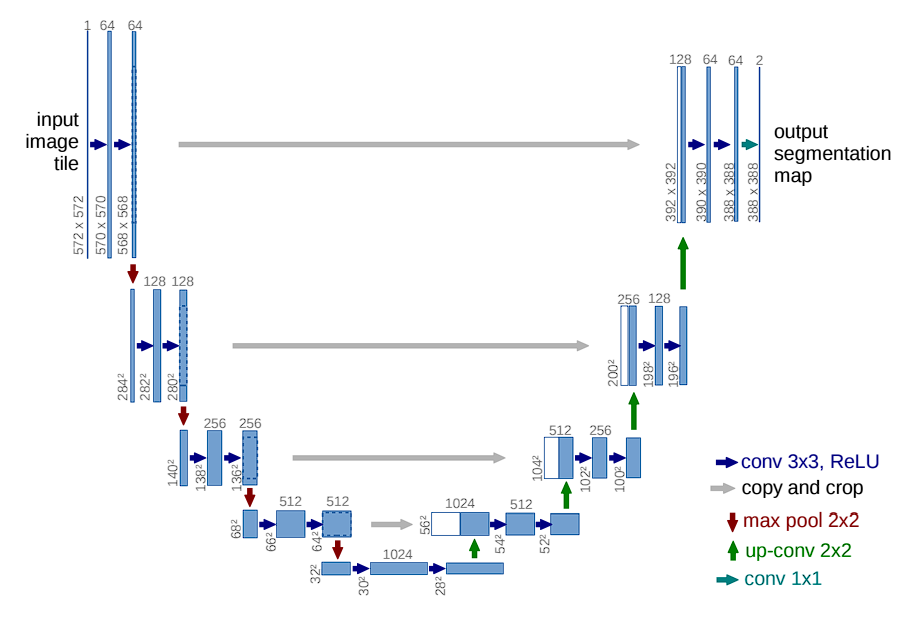

In [1]:
import torch
import torch.nn as nn
from torchvision import models
from torch.nn.functional import relu
import numpy as np
import matplotlib.pyplot as plt
import os
import shutil
from PIL import Image
from torch.utils.data import Dataset, DataLoader,random_split
from torchvision import transforms as T
from tqdm import tqdm
from torchvision.utils import save_image,make_grid

In [2]:
import warnings
warnings.filterwarnings('ignore')

In [3]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [4]:
!pip install -q kaggle

!mkdir ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

!kaggle datasets download -d kwentar/blur-dataset

!unzip blur-dataset.zip -d /content/blur-dataset

mkdir: cannot create directory ‘/root/.kaggle’: File exists
Dataset URL: https://www.kaggle.com/datasets/kwentar/blur-dataset
License(s): CC0-1.0
100% 1.49G/1.49G [00:17<00:00, 328MB/s]
100% 1.49G/1.49G [00:17<00:00, 89.3MB/s]
Archive:  blur-dataset.zip
  inflating: /content/blur-dataset/blur_dataset_scaled/defocused_blurred/0_IPHONE-SE_F.JPG  
  inflating: /content/blur-dataset/blur_dataset_scaled/defocused_blurred/100_NIKON-D3400-35MM_F.JPG  
  inflating: /content/blur-dataset/blur_dataset_scaled/defocused_blurred/101_NIKON-D3400-35MM_F.JPG  
  inflating: /content/blur-dataset/blur_dataset_scaled/defocused_blurred/102_NIKON-D3400-35MM_F.JPG  
  inflating: /content/blur-dataset/blur_dataset_scaled/defocused_blurred/103_HUAWEI-P20_F.jpg  
  inflating: /content/blur-dataset/blur_dataset_scaled/defocused_blurred/104_IPHONE-SE_F.jpg  
  inflating: /content/blur-dataset/blur_dataset_scaled/defocused_blurred/105_IPHONE-SE_F.jpg  
  inflating: /content/blur-dataset/blur_dataset_scaled/defocu

In [5]:
!ls /content/drive/MyDrive
print("\n")
!ls /content/blur-dataset

 231001_Shvetang_A_1.ipynb
'Ai²TS-1_(XII)_QP, ANS & Soln-14-09-22.pdf'
'AI ML Tasks.gdoc'
'BOOK REVIEW : LORD EDGWARE DIES.gdoc'
'Brain and Cognitive Society, IITK.gdoc'
'Colab Notebooks'
 computer_software.gdoc
 dynamics.pdf
 Expenses_Shvetang.gsheet
 hex.txt
 horse2zebra
'Kannada Problems.gsheet'
 Learning.gdoc
'Lucknow Agencies.gsheet'
'Mall Food Service.gdoc'
'MOVIE REVIEW : DUNKIRK.gdoc'
'newton_raphson_solver (1).py'
 newton_raphson_solver.py
'Outcome Prompt Evaluation.gsheet'
 pokemon
 pokemon.zip
 QuizQuestions.gdoc
'Resume (1).pdf'
 Resume-2.pdf
'Resume (2).pdf'
 Resume.pdf
'Secretary Recruitment Tasks.gdoc'
 SOP.gdoc
'Statement of Purpose - ISTA.gdoc'
'Statement of Purpose - TIFR.gdoc'
'Summary of “The Peony Lantern”.gdoc'
 Summer.gdoc
 test.gsheet
'Test Results Summary.gsheet'
'Untitled document.gdoc'
'Untitled project.gscript'
'Untitled spreadsheet.gsheet'
 UTIITSL_ePAN.pdf
'vvx-vzds-kxw - Dec 17, 2020.pdf'
'WhatsApp Image 2024-06-17 at 00.29.17.jpeg'
'Wildfires Analysis.gd

In [6]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(device)

cuda


In [7]:
batch_size = 8
image_size= 256
model_path="/content/drive/MyDrive/UNet.pth"
epochs=21
root_path="/content/blur-dataset"

In [8]:
class ImageDataset(Dataset):
    def __init__(self,root_path,train_path,val_path="sharp"):
        self.images=sorted(f"{root_path}/{train_path}/{i}" for i in os.listdir(root_path + f"/{train_path}"))
        self.masks=sorted(f"{root_path}/{val_path}/{i}" for i in os.listdir(root_path + f"/{val_path}"))

        self.transform=T.Compose([
            T.Resize((256,256)),
            T.ToTensor()
        ])
    def __getitem__(self,idx):
        img=Image.open(self.images[idx]).convert("RGB")
        mask=Image.open(self.masks[idx]).convert("RGB")
        return(self.transform(img),self.transform(mask))
    def __len__(self):
        return len(self.images)


In [9]:
dataset=ImageDataset(root_path,"motion_blurred")
train_dataset, test_dataset = random_split(dataset,[0.8,0.2])

In [10]:
print(len(train_dataset))
print(len(test_dataset))

280
70


In [11]:
train_dataloader=DataLoader(dataset=train_dataset,shuffle=True,batch_size=batch_size)
test_dataloader=DataLoader(dataset=test_dataset,shuffle=True,batch_size=batch_size)


In [12]:
sample_dir = "/content/UNet_Generated"
os.makedirs(sample_dir, exist_ok=True)

def save_samples(index,images,model,show=True):
    masks = model(images)
    mask_fname = 'generated-masks-{0:0=4d}.png'.format(index)
    save_image(masks, os.path.join(sample_dir, mask_fname), nrow=4)
    print('Saving', mask_fname)
    if show:
        fig, ax = plt.subplots(figsize=(4,2))
        ax.set_xticks([]); ax.set_yticks([])
        ax.imshow(make_grid(masks.cpu().detach(), nrow=4).permute(1, 2, 0))

In [33]:
def show_batch(image_batch, title):
    image_batch = torch.clamp(image_batch, 0, 1)
    plt.figure(figsize=(20,7))
    grid = make_grid(image_batch, nrow=8)
    plt.imshow(grid.cpu().detach().numpy().transpose(1,2,0))
    plt.title(title)
    plt.axis('off')
    plt.show()

In [29]:
class UNet(nn.Module):
    def __init__(self):
        super().__init__()

        self.e11 = nn.Conv2d(3, 64, kernel_size=3, padding=1)
        self.e12 = nn.Conv2d(64, 64, kernel_size=3, padding=1)
        self.pool1 = nn.MaxPool2d(kernel_size=2, stride=2)

        self.e21 = nn.Conv2d(64, 128, kernel_size=3, padding=1)
        self.e22 = nn.Conv2d(128, 128, kernel_size=3, padding=1)
        self.pool2 = nn.MaxPool2d(kernel_size=2, stride=2)

        self.e31 = nn.Conv2d(128, 256, kernel_size=3, padding=1)
        self.e32 = nn.Conv2d(256, 256, kernel_size=3, padding=1)
        self.pool3 = nn.MaxPool2d(kernel_size=2, stride=2)

        self.e41 = nn.Conv2d(256, 512, kernel_size=3, padding=1)
        self.e42 = nn.Conv2d(512, 512, kernel_size=3, padding=1)
        self.pool4 = nn.MaxPool2d(kernel_size=2, stride=2)

        self.e51 = nn.Conv2d(512, 1024, kernel_size=3, padding=1)
        self.e52 = nn.Conv2d(1024, 1024, kernel_size=3, padding=1)

        self.upconv1 = nn.ConvTranspose2d(1024, 512, kernel_size=2, stride=2)
        self.d11 = nn.Conv2d(1024, 512, kernel_size=3, padding=1)
        self.d12 = nn.Conv2d(512, 512, kernel_size=3, padding=1)

        self.upconv2 = nn.ConvTranspose2d(512, 256, kernel_size=2, stride=2)
        self.d21 = nn.Conv2d(512, 256, kernel_size=3, padding=1)
        self.d22 = nn.Conv2d(256, 256, kernel_size=3, padding=1)

        self.upconv3 = nn.ConvTranspose2d(256, 128, kernel_size=2, stride=2)
        self.d31 = nn.Conv2d(256, 128, kernel_size=3, padding=1)
        self.d32 = nn.Conv2d(128, 128, kernel_size=3, padding=1)

        self.upconv4 = nn.ConvTranspose2d(128, 64, kernel_size=2, stride=2)
        self.d41 = nn.Conv2d(128, 64, kernel_size=3, padding=1)
        self.d42 = nn.Conv2d(64, 64, kernel_size=3, padding=1)

        # Output layer
        self.outconv = nn.Conv2d(64, 3, kernel_size=1)

    def forward(self, x):
        # Encoder
        xe11 = relu(self.e11(x))
        xe12 = relu(self.e12(xe11))
        xp1 = self.pool1(xe12)

        xe21 = relu(self.e21(xp1))
        xe22 = relu(self.e22(xe21))
        xp2 = self.pool2(xe22)

        xe31 = relu(self.e31(xp2))
        xe32 = relu(self.e32(xe31))
        xp3 = self.pool3(xe32)

        xe41 = relu(self.e41(xp3))
        xe42 = relu(self.e42(xe41))
        xp4 = self.pool4(xe42)

        xe51 = relu(self.e51(xp4))
        xe52 = relu(self.e52(xe51))

        # Decoder
        xu1 = self.upconv1(xe52)
        xu11 = torch.cat([xu1, xe42], dim=1)
        xd11 = relu(self.d11(xu11))
        xd12 = relu(self.d12(xd11))

        xu2 = self.upconv2(xd12)
        xu22 = torch.cat([xu2, xe32], dim=1)
        xd21 = relu(self.d21(xu22))
        xd22 = relu(self.d22(xd21))

        xu3 = self.upconv3(xd22)
        xu33 = torch.cat([xu3, xe22], dim=1)
        xd31 = relu(self.d31(xu33))
        xd32 = relu(self.d32(xd31))

        xu4 = self.upconv4(xd32)
        xu44 = torch.cat([xu4, xe12], dim=1)
        xd41 = relu(self.d41(xu44))
        xd42 = relu(self.d42(xd41))

        # Output layer
        out = self.outconv(xd42)

        return out

In [ ]:
model = UNet().to(device)
criterion = nn.MSELoss()                                    #L2 Criterion
optimizer = torch.optim.SGD(model.parameters(), lr=0.01)

  0%|          | 0/20 [00:00<?, ?it/s]

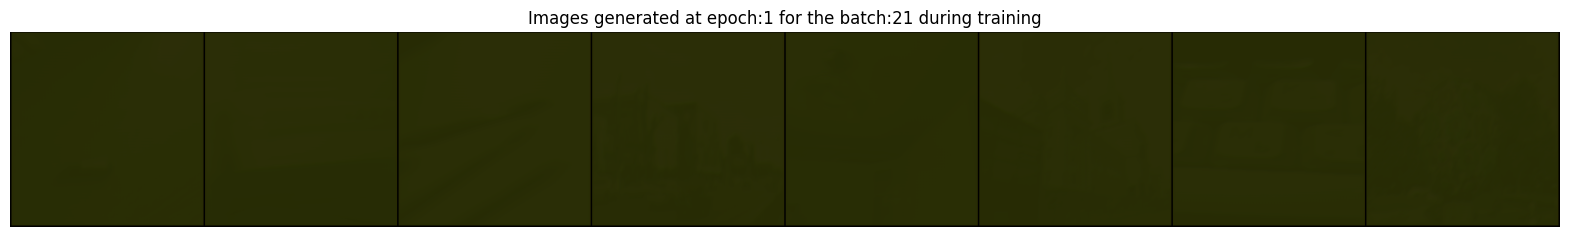

  5%|▌         | 1/20 [01:16<24:19, 76.79s/it]

Epoch [1/20], Train Loss: 0.1827, Val Loss: 0.5586


 10%|█         | 2/20 [02:31<22:38, 75.45s/it]

Epoch [2/20], Train Loss: 0.1145, Val Loss: 0.3261


 15%|█▌        | 3/20 [03:45<21:12, 74.84s/it]

Epoch [3/20], Train Loss: 0.0636, Val Loss: 0.1980


 20%|██        | 4/20 [04:57<19:43, 73.94s/it]

Epoch [4/20], Train Loss: 0.0488, Val Loss: 0.1859


 25%|██▌       | 5/20 [06:12<18:33, 74.27s/it]

Epoch [5/20], Train Loss: 0.0476, Val Loss: 0.1839


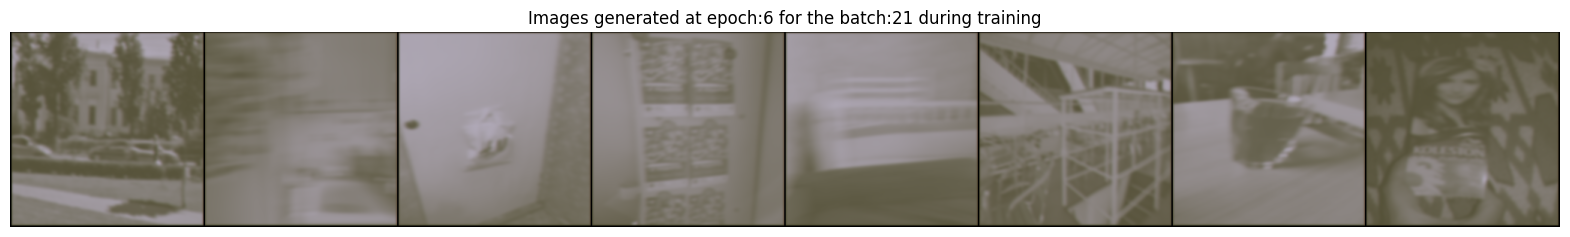

 30%|███       | 6/20 [07:28<17:26, 74.77s/it]

Epoch [6/20], Train Loss: 0.0472, Val Loss: 0.1825


 35%|███▌      | 7/20 [08:46<16:24, 75.74s/it]

Epoch [7/20], Train Loss: 0.0468, Val Loss: 0.1814


 40%|████      | 8/20 [10:02<15:09, 75.77s/it]

Epoch [8/20], Train Loss: 0.0465, Val Loss: 0.1804


 45%|████▌     | 9/20 [11:23<14:13, 77.58s/it]

Epoch [9/20], Train Loss: 0.0463, Val Loss: 0.1794


 50%|█████     | 10/20 [12:41<12:55, 77.59s/it]

Epoch [10/20], Train Loss: 0.0461, Val Loss: 0.1787


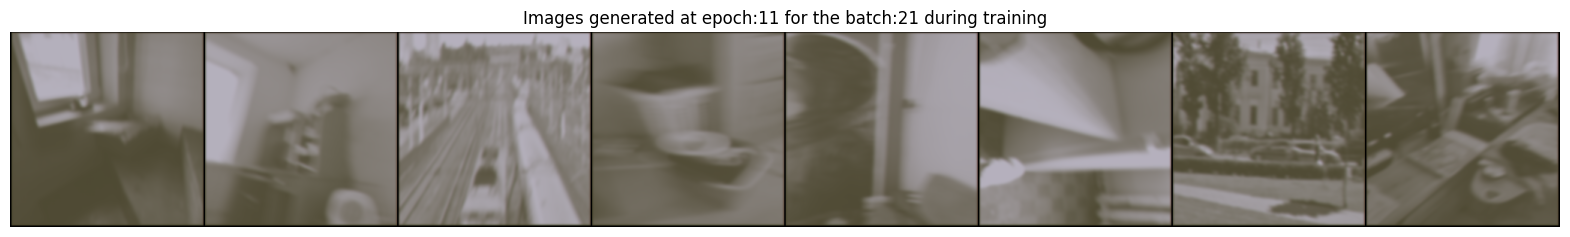

 55%|█████▌    | 11/20 [14:02<11:47, 78.66s/it]

Epoch [11/20], Train Loss: 0.0459, Val Loss: 0.1782


 60%|██████    | 12/20 [15:24<10:36, 79.60s/it]

Epoch [12/20], Train Loss: 0.0457, Val Loss: 0.1775


 65%|██████▌   | 13/20 [16:45<09:20, 80.14s/it]

Epoch [13/20], Train Loss: 0.0456, Val Loss: 0.1771


 70%|███████   | 14/20 [18:03<07:56, 79.44s/it]

Epoch [14/20], Train Loss: 0.0455, Val Loss: 0.1766


 75%|███████▌  | 15/20 [19:20<06:33, 78.78s/it]

Epoch [15/20], Train Loss: 0.0454, Val Loss: 0.1763


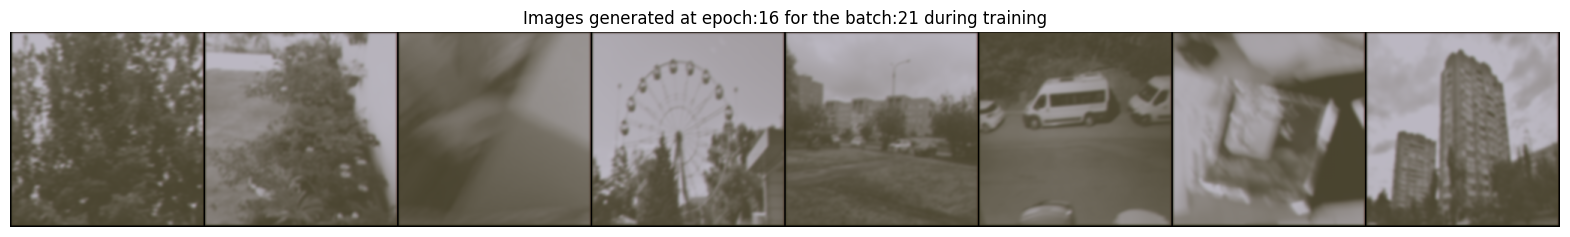

 80%|████████  | 16/20 [20:37<05:13, 78.35s/it]

Epoch [16/20], Train Loss: 0.0453, Val Loss: 0.1759


 85%|████████▌ | 17/20 [22:03<04:01, 80.56s/it]

Epoch [17/20], Train Loss: 0.0452, Val Loss: 0.1757


 90%|█████████ | 18/20 [23:21<02:39, 79.71s/it]

Epoch [18/20], Train Loss: 0.0452, Val Loss: 0.1754


 95%|█████████▌| 19/20 [25:06<01:27, 87.24s/it]

Epoch [19/20], Train Loss: 0.0451, Val Loss: 0.1752


100%|██████████| 20/20 [26:25<00:00, 79.26s/it]

Epoch [20/20], Train Loss: 0.0451, Val Loss: 0.1751


In [ ]:
metrics=[[],[]]

for epoch in tqdm(range(epochs)):
    model.train()
    train_loss = 0
    for idx,pair in enumerate(train_dataloader):
        images=pair[0].to(device)
        masks=pair[1].to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, masks)
        loss.backward()
        optimizer.step()
        train_loss += loss.item()

        #print(f"{idx+1}/9 done ...")
        if epoch%5==0 and idx==20:
           show_batch(outputs,f"Images generated at epoch:{epoch+1} for one batch during training")

    train_loss /= len(train_dataloader)
    metrics[0].append(train_loss)

    model.eval()
    val_loss = 0
    with torch.no_grad():
        for idx,pair in enumerate(train_dataloader):
            images=pair[0].to(device)
            masks=pair[1].to(device)

            outputs = model(images)
            loss = criterion(outputs, masks)
            val_loss += loss.item()

            #print(f"{idx+1}/9 done ...")

    val_loss /= len(test_dataloader)
    metrics[1].append(val_loss)

    print(f"Epoch [{epoch+1}/{epochs}], Train Loss: {train_loss:.4f}, Val Loss: {val_loss:.4f}")

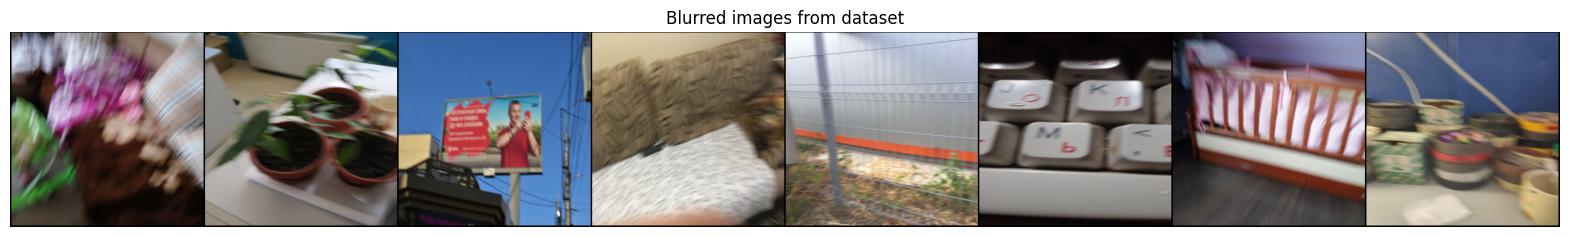

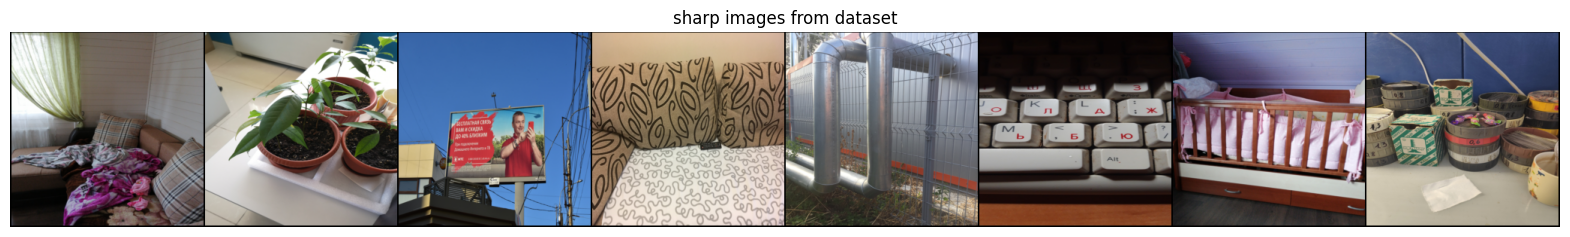

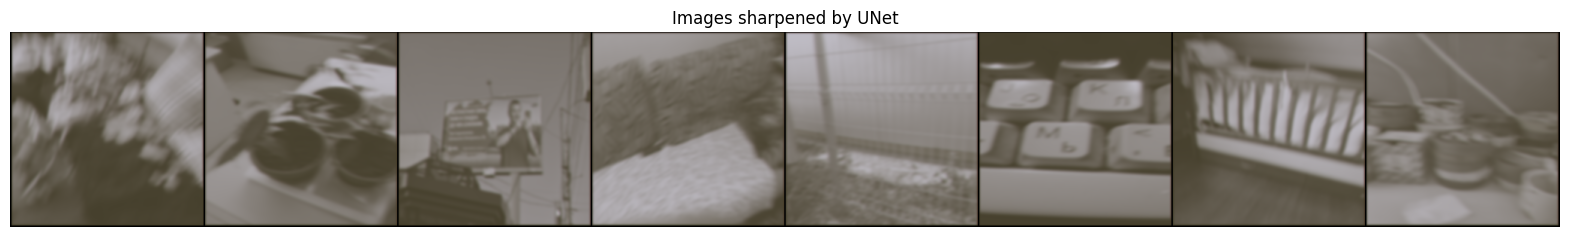

In [ ]:
data_iter=iter(train_dataloader)
first_batch=next(data_iter)
images,masks=first_batch
outputs=model(images.to(device))
show_batch(images.to(device),"Blurred images from dataset")
show_batch(masks.to(device),"Sharp images from dataset")
show_batch(outputs.to(device),"Images sharpened by UNet")

# Key Changes Made
- Changed Average Pooling to Max Pooling
- Changed optimzer to AdamW
- Clipped image outputs to [0,1]
- L1 Loss


In [30]:
model = UNet().to(device)
criterion = torch.nn.L1Loss()                                    #L1 Loss
optimizer = torch.optim.AdamW(model.parameters(), lr=0.001, weight_decay=1e-4)

  0%|          | 0/21 [00:00<?, ?it/s]

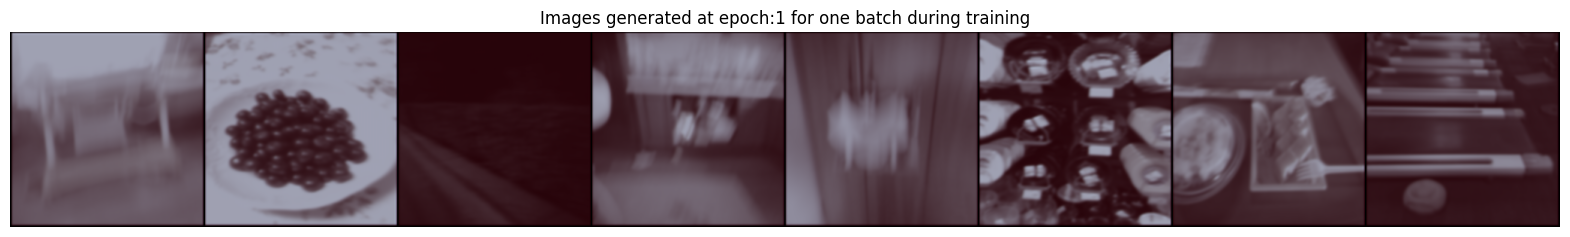

  5%|▍         | 1/21 [01:02<20:40, 62.04s/it]

Epoch [1/21], Train Loss: 0.1710, Val Loss: 0.6353


 10%|▉         | 2/21 [02:03<19:29, 61.56s/it]

Epoch [2/21], Train Loss: 0.1651, Val Loss: 0.6269


 14%|█▍        | 3/21 [03:03<18:20, 61.14s/it]

Epoch [3/21], Train Loss: 0.1629, Val Loss: 0.6217


 19%|█▉        | 4/21 [04:08<17:41, 62.43s/it]

Epoch [4/21], Train Loss: 0.1614, Val Loss: 0.6137


 24%|██▍       | 5/21 [05:11<16:41, 62.59s/it]

Epoch [5/21], Train Loss: 0.1588, Val Loss: 0.6109


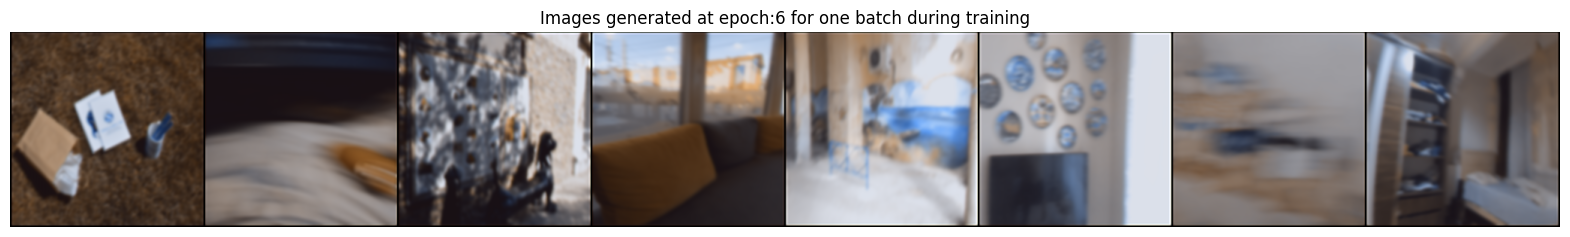

 29%|██▊       | 6/21 [06:13<15:37, 62.48s/it]

Epoch [6/21], Train Loss: 0.1580, Val Loss: 0.6101


 33%|███▎      | 7/21 [07:14<14:30, 62.17s/it]

Epoch [7/21], Train Loss: 0.1565, Val Loss: 0.6068


 38%|███▊      | 8/21 [08:16<13:26, 62.07s/it]

Epoch [8/21], Train Loss: 0.1571, Val Loss: 0.6136


 43%|████▎     | 9/21 [09:18<12:25, 62.09s/it]

Epoch [9/21], Train Loss: 0.1579, Val Loss: 0.6052


 48%|████▊     | 10/21 [10:20<11:22, 62.03s/it]

Epoch [10/21], Train Loss: 0.1602, Val Loss: 0.6206


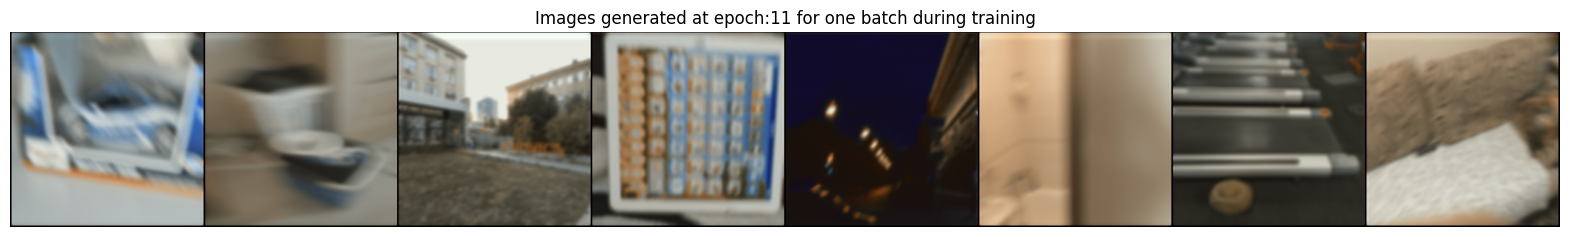

 52%|█████▏    | 11/21 [11:23<10:22, 62.21s/it]

Epoch [11/21], Train Loss: 0.1556, Val Loss: 0.6007


 57%|█████▋    | 12/21 [12:26<09:20, 62.32s/it]

Epoch [12/21], Train Loss: 0.1545, Val Loss: 0.6334


 62%|██████▏   | 13/21 [13:28<08:17, 62.24s/it]

Epoch [13/21], Train Loss: 0.1604, Val Loss: 0.5976


 67%|██████▋   | 14/21 [14:30<07:16, 62.33s/it]

Epoch [14/21], Train Loss: 0.1573, Val Loss: 0.5983


 71%|███████▏  | 15/21 [15:39<06:25, 64.23s/it]

Epoch [15/21], Train Loss: 0.1691, Val Loss: 0.6142


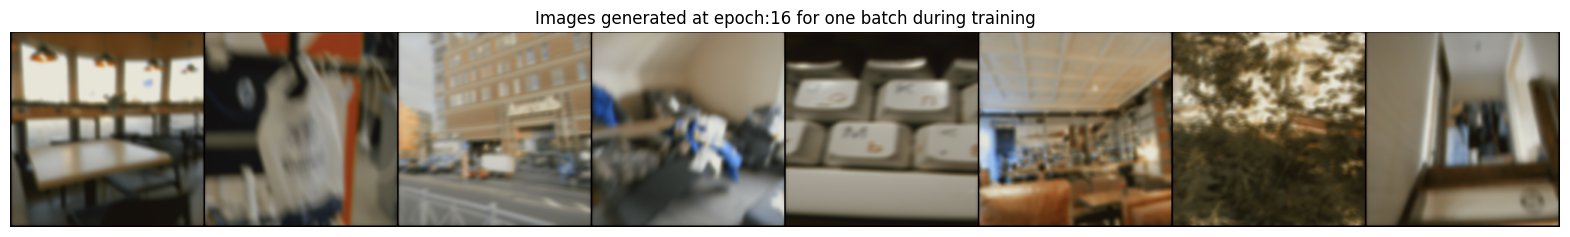

 76%|███████▌  | 16/21 [16:47<05:26, 65.29s/it]

Epoch [16/21], Train Loss: 0.1550, Val Loss: 0.6055


 81%|████████  | 17/21 [17:54<04:23, 65.84s/it]

Epoch [17/21], Train Loss: 0.1548, Val Loss: 0.5963


 86%|████████▌ | 18/21 [19:01<03:19, 66.35s/it]

Epoch [18/21], Train Loss: 0.1564, Val Loss: 0.5925


 90%|█████████ | 19/21 [20:10<02:13, 66.97s/it]

Epoch [19/21], Train Loss: 0.1558, Val Loss: 0.6178


 95%|█████████▌| 20/21 [21:19<01:07, 67.63s/it]

Epoch [20/21], Train Loss: 0.1552, Val Loss: 0.6038


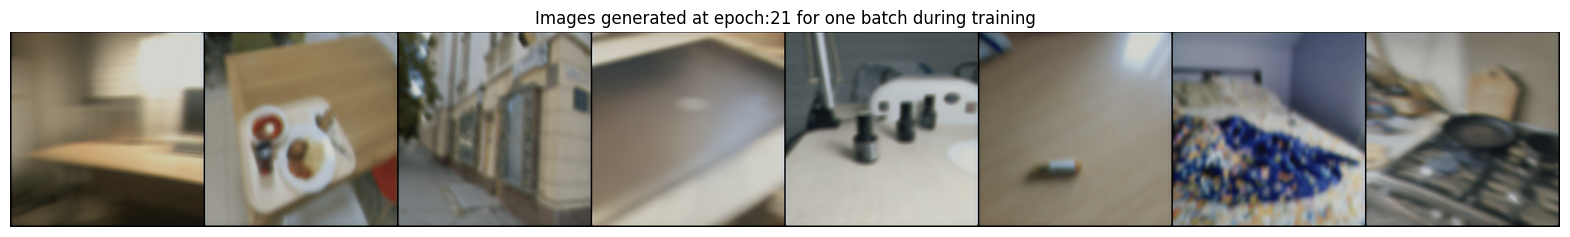

100%|██████████| 21/21 [22:28<00:00, 64.21s/it]

Epoch [21/21], Train Loss: 0.1552, Val Loss: 0.5930


In [34]:
metrics=[[],[]]

for epoch in tqdm(range(epochs)):
    model.train()
    train_loss = 0
    for idx,pair in enumerate(train_dataloader):
        images=pair[0].to(device)
        masks=pair[1].to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, masks)
        loss.backward()
        optimizer.step()
        train_loss += loss.item()

        #print(f"{idx+1}/9 done ...")
        if epoch%5==0 and idx==20:
           show_batch(outputs,f"Images generated at epoch:{epoch+1} for one batch during training")

    train_loss /= len(train_dataloader)
    metrics[0].append(train_loss)

    model.eval()
    val_loss = 0
    with torch.no_grad():
        for idx,pair in enumerate(train_dataloader):
            images=pair[0].to(device)
            masks=pair[1].to(device)

            outputs = model(images)
            loss = criterion(outputs, masks)
            val_loss += loss.item()

            #print(f"{idx+1}/9 done ...")

    val_loss /= len(test_dataloader)
    metrics[1].append(val_loss)

    print(f"Epoch [{epoch+1}/{epochs}], Train Loss: {train_loss:.4f}, Val Loss: {val_loss:.4f}")

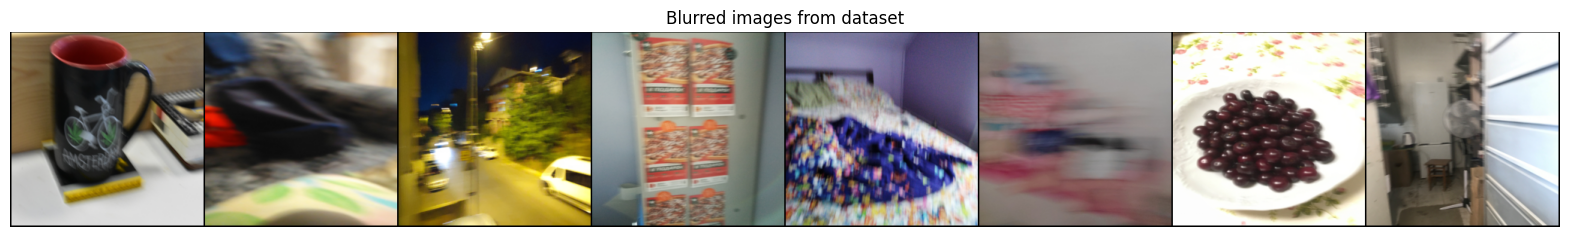

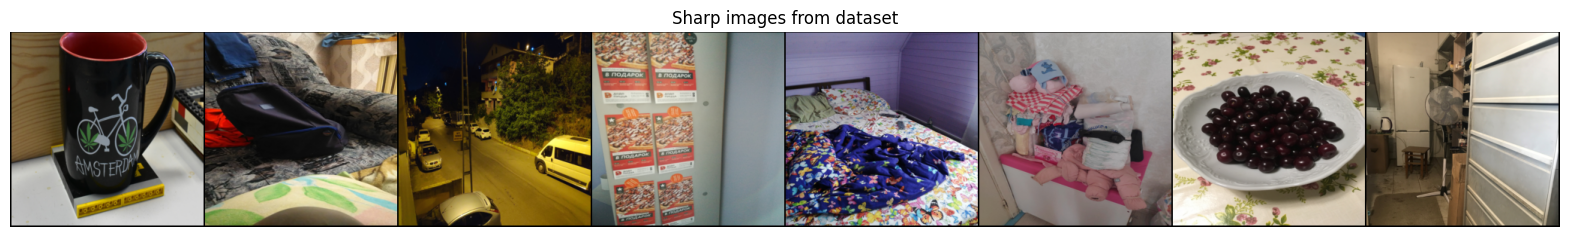

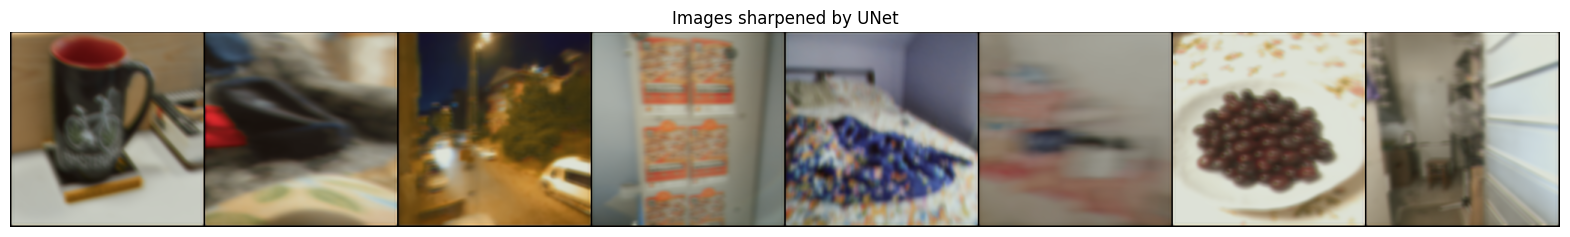

In [37]:
data_iter=iter(train_dataloader)
first_batch=next(data_iter)
images,masks=first_batch
outputs=model(images.to(device))
show_batch(images.to(device),"Blurred images from dataset")
show_batch(masks.to(device),"Sharp images from dataset")
show_batch(outputs.to(device),"Images sharpened by UNet")

Text(0.5, 1.0, 'Losses')

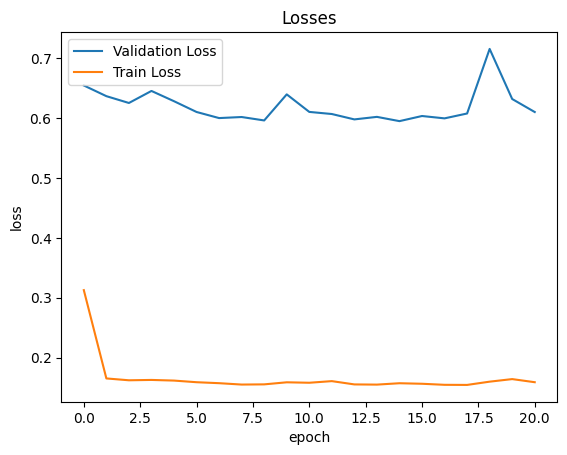

In [28]:
plt.plot(metrics[1], '-')
plt.plot(metrics[0], '-')
plt.xlabel('epoch')
plt.ylabel('loss')
plt.legend(['Validation Loss', 'Train Loss'])
plt.title('Losses')

# Interpretation

- L1/L2 loss penalizes being “confident and wrong”, so it favors blurry averages of plausible outputs.
- The model is not incentivized to sharpen textures or fine edges.
- UNet has no semantic awareness of "what a sharp sofa looks like" — it's just minimizing pixel error.

The losses stabilized quickly and the model is giving a safe, averaged out output.    
However, it must be noted that
- the dataset is not very clean (some sharp images are shaky and positions of objects in them have shifted from the blurred image)
- basic UNet architectures such as these are better suited to tasks like segmentation, where the most important comparison needed is the pixel to pixel comparison (the paper being followed uses this architecture for biomedical image segmentation)